In [1]:
import time

import matplotlib.pyplot as plt
import nest
import nest.raster_plot
import numpy as np
import scipy.special as sp


              -- N E S T --
  Copyright (C) 2004 The NEST Initiative

 Version: 3.9.0
 Built: Oct  2 2025 07:05:42

 This program is provided AS IS and comes with
 NO WARRANTY. See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.



In [2]:
def LambertWm1(x):
    # Using scipy to mimic the gsl_sf_lambert_Wm1 function.
    return sp.lambertw(x, k=-1 if x < 0 else 0).real


def ComputePSPnorm(tauMem, CMem, tauSyn):
    a = tauMem / tauSyn
    b = 1.0 / tauSyn - 1.0 / tauMem

    # time of maximum
    t_max = 1.0 / b * (-LambertWm1(-np.exp(-1.0 / a) / a) - 1.0 / a)

    # maximum of PSP for current of unit amplitude
    return (
        np.exp(1.0)
        / (tauSyn * CMem * b)
        * ((np.exp(-t_max / tauMem) - np.exp(-t_max / tauSyn)) / b - t_max * np.exp(-t_max / tauSyn))
    )


nest.ResetKernel()

In [3]:
startbuild = time.time()

dt = 0.1  # the resolution in ms
simtime = 1000.0  # Simulation time in ms
delay = 1.5  # synaptic delay in ms

g = 5.0  # ratio inhibitory weight/excitatory weight, g > 4.0 represents an inhibition-dominated state (5.0)
eta = 1.0  # external rate relative to threshold rate (2.0)
epsilon = 0.1  # connection probability

order = 2500
NE = 4 * order  # number of excitatory neurons
NI = 1 * order  # number of inhibitory neurons
N_neurons = NE + NI  # number of neurons in total
N_rec = 50  # record from 50 neurons

CE = int(epsilon * NE)  # number of excitatory synapses per neuron
CI = int(epsilon * NI)  # number of inhibitory synapses per neuron
C_tot = int(CI + CE)  # total number of synapses per neuron

tauSyn = 0.5  # synaptic time constant in ms
tauMem = 20.0  # time constant of membrane potential in ms
CMem = 250.0  # capacitance of membrane in in pF
theta = 20.0  # membrane threshold potential in mV
neuron_params = {
    "C_m": CMem,
    "tau_m": tauMem,
    "tau_syn_ex": tauSyn,
    "tau_syn_in": tauSyn,
    "t_ref": 2.0,
    "E_L": 0.0,
    "V_reset": 0.0,
    "V_m": 0.0,
    "V_th": theta,
}
J = 0.1  # postsynaptic amplitude in mV
J_unit = ComputePSPnorm(tauMem, CMem, tauSyn)
J_ex = J / J_unit  # amplitude of excitatory postsynaptic current
J_in = -g * J_ex  # amplitude of inhibitory postsynaptic current

nu_th = (theta * CMem) / (J_ex * CE * np.exp(1) * tauMem * tauSyn) # external input rate s.t. a neuron could maintain its voltage level around threshold
nu_ex = eta * nu_th # eta = 2 which means the network will fire automatically even without internal circuit
p_rate = 1000.0 * nu_ex * CE # possion generator: each neuron receive N=CE possion input

$$\mu_{total} =J_{ex} C_E \nu_{ext} + J_{ex} C_E \nu_E - g J_{ex} C_I \nu_I$$

In [4]:
nest.resolution = dt
nest.print_time = True
nest.overwrite_files = True

print("Building network")

nodes_ex = nest.Create("iaf_psc_alpha", NE, params=neuron_params)
nodes_in = nest.Create("iaf_psc_alpha", NI, params=neuron_params)
noise = nest.Create("poisson_generator", params={"rate": p_rate})
espikes = nest.Create("spike_recorder")
ispikes = nest.Create("spike_recorder")

espikes.set(label="brunel-py-ex", record_to="ascii")
ispikes.set(label="brunel-py-in", record_to="ascii")

print("Connecting devices")

Building network

Apr 04 23:53:37 SimulationManager::set_status [Info]: 
    Temporal Connecting devices
resolution changed from 0.1 to 0.1 ms.


In [5]:
####################################################
sigma_ex = 0.2 * J_ex 
sigma_in = 0.2 * abs(J_in)

nest.CopyModel("static_synapse", "excitatory")
nest.CopyModel("static_synapse", "inhibitory")

syn_ex = {
    "synapse_model": "excitatory",
    "weight": nest.math.redraw(
        nest.random.normal(mean=J_ex, std=sigma_ex),
        min=0.0,
        max=J_ex + 5.0 * sigma_ex
    ),
    "delay": delay
}

syn_in = {
    "synapse_model": "inhibitory",
    "weight": nest.math.redraw(
        nest.random.normal(mean=J_in, std=sigma_in),
        min=J_in - 5.0 * sigma_in,
        max=0.0
    ),
    "delay": delay
}

####################################################

nest.Connect(noise, nodes_ex, syn_spec=syn_ex)
nest.Connect(noise, nodes_in, syn_spec=syn_ex)

nest.Connect(nodes_ex[:N_rec], espikes, syn_spec=syn_ex)
nest.Connect(nodes_in[:N_rec], ispikes, syn_spec=syn_ex)

conn_params_ex = {"rule": "fixed_indegree", "indegree": CE}
nest.Connect(nodes_ex, nodes_ex + nodes_in, conn_params_ex, syn_ex)

conn_params_in = {"rule": "fixed_indegree", "indegree": CI}
nest.Connect(nodes_in, nodes_ex + nodes_in, conn_params_in, syn_in)

In [6]:
nest.Simulate(simtime)


Apr 04 23:53:38 NodeManager::prepare_nodes [Info]: 
    Preparing 12503 nodes for simulation.

Apr 04 23:53:39 SimulationManager::run [Warning]: 
    The requested simulation time is not an integer multiple of the minimal 
    delay in the network. This may result in inconsistent results under the 
    following conditions: (i) A network contains more than one source of 
    randomness, e.g., two different poisson_generators, and (ii) Simulate is 
    called repeatedly with simulation times that are not multiples of the 
    minimal delay.

Apr 04 23:53:39 SimulationManager::start_updating_ [Info]: 
    Number of local nodes: 12503
    Simulation time (ms): 1000
    Number of OpenMP threads: 1
    Not using MPI

[  52% ] Model time: 519.0 ms, Real-time factor: 5.3379 factor: 5.2050

In [7]:
endsimulate = time.time()

[  74% ] Model time: 733.5 ms, Real-time factor: 5.2971

[ 100% ] Model time: 999.0 ms, Real-time factor: 5.2868 5.3098

Apr 04 23:53:44 SimulationManager::run [Info]: 
    Simulation finished.


In [8]:
events_ex = espikes.n_events
events_in = ispikes.n_events

In [9]:
rate_ex = events_ex / simtime * 1000.0 / N_rec
rate_in = events_in / simtime * 1000.0 / N_rec

In [10]:
num_synapses_ex = nest.GetDefaults("excitatory")["num_connections"]
num_synapses_in = nest.GetDefaults("inhibitory")["num_connections"]
num_synapses = num_synapses_ex + num_synapses_in

In [11]:
print("Brunel network simulation (Python)")
print(f"Number of neurons : {N_neurons}")
print(f"Number of synapses: {num_synapses}")
print(f"       Excitatory : {num_synapses_ex}")
print(f"       Inhibitory : {num_synapses_in}")
print(f"Excitatory rate   : {rate_ex:.2f} spks/s")
print(f"Inhibitory rate   : {rate_in:.2f} spks/s")
# print(f"Building time     : {build_time:.2f} s")
# print(f"Simulation time   : {sim_time:.2f} s")

Brunel network simulation (Python)
Number of neurons : 12500
Number of synapses: 15637600
       Excitatory : 12512600
       Inhibitory : 3125000
Excitatory rate   : 9.32 spks/s
Inhibitory rate   : 8.28 spks/s


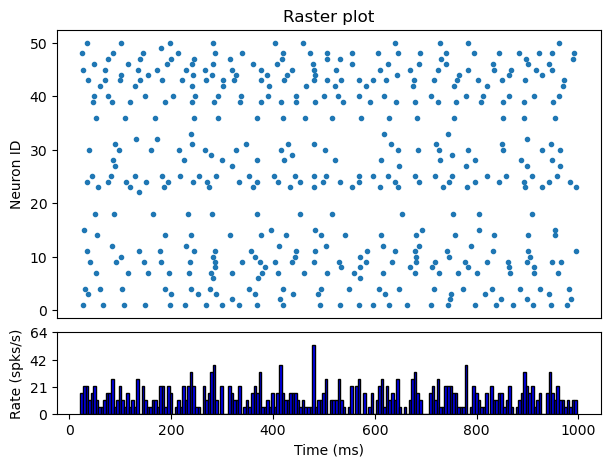

In [12]:
nest.raster_plot.from_device(espikes, hist=True)
plt.show()